Name:    BRIGHT OPPONG BOATENG
ID:      2526500409

In [158]:
import pandas as pd
import numpy 
import matplotlib.pyplot

In [159]:
df=pd.read_csv("car_price_prediction.csv")

In [160]:
df.columns = df.columns.str.strip()

In [161]:
df.head()
df.dtypes

ID                   int64
Price                int64
Levy                object
Manufacturer        object
Model               object
Prod. year           int64
Category            object
Leather interior    object
Fuel type           object
Engine volume       object
Mileage             object
Cylinders            int64
Gear box type       object
Drive wheels        object
Doors               object
Wheel               object
Color               object
Airbags              int64
dtype: object

In [162]:
df['Mileage'] = df['Mileage'].astype(str)  # ensure string
df['Mileage'] = df['Mileage'].str.replace(' km', '', regex=False)
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

In [163]:
df['Levy'] = df['Levy'].replace('-', None)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

# Optional: fill missing values
df['Levy'] = df['Levy'].fillna(0)

In [164]:
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

In [165]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Manufacturer'] = le.fit_transform(df['Manufacturer'])

In [166]:
df = df.drop(columns=['ID'])

In [167]:
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))

Price                  0
Levy                   0
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume       1931
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64


In [168]:
print(df.dtypes)
print(df.head())

Price                 int64
Levy                float64
Manufacturer          int64
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume       float64
Mileage               int64
Cylinders             int64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object
   Price    Levy  Manufacturer    Model  Prod. year   Category  \
0  13328  1399.0            32   RX 450        2010       Jeep   
1  16621  1018.0             8  Equinox        2011       Jeep   
2   8467     0.0            21      FIT        2006  Hatchback   
3   3607   862.0            16   Escape        2011       Jeep   
4  11726   446.0            21      FIT        2014  Hatchback   

  Leather interior Fuel type  Engine volume  Mileage  Cylinders Gear box type  \
0              Yes    Hybrid    

In [187]:
# Features (X)

X = df[['Mileage', 'Engine volume', 'Manufacturer', 'Cylinders']]
y = df['Price']

# Encode only the categorical column
X = pd.get_dummies(X, columns=['Manufacturer'], drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

model = LinearRegression()
model.fit(x_train, y_train)
# Target (y)
y = df['Price']

In [188]:
x.head()

,Mileage,Engine volume,Manufacturer,Cylinders
0,186005,3.5,32,6
1,192000,3.0,8,6
2,200000,1.3,21,4
3,168966,2.5,16,4
4,91901,1.3,21,4


In [189]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=28, test_size=40)

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [190]:
y_pred =model.predict(x_test)

In [191]:
y_pred

array([17398.22767743, 19524.05003544, 16537.55033395, 17806.48933963,
       18976.95907212, 17176.66823032, 16447.32412493, 19248.25787401,
       18778.05233589, 18232.38087313, 18221.32986785, 18456.36823027,
       17303.96367588, 18867.74708142, 16448.78878116, 18234.60414968,
       21859.21277843, 17806.3615771 , 19505.96569443, 21525.93040506,
       17565.39941558, 19632.39545   , 17806.72469167, 18235.01090524,
       10580.88744818, 17398.61738006, 18234.07101007, 18822.67163747,
       17806.09932769, 18166.41620263, 16987.52046546, 17806.75495122,
       18234.80275317, 18221.2351353 , 17806.38847448, 18456.29960835,
       17776.66007942, 19257.10486605, 17127.26885165, 17824.28323956])

In [192]:
y_test

1250     10820
10847      314
17239    51802
3088        20
15499     6272
7528     34497
17346      470
13116      862
3632     20005
10776    10036
9499      1490
2760     12544
7426      8781
642      47042
1887     12544
7405     43815
16484     5018
10147    10873
12106     8938
5937     14113
13930    23521
12663      706
18968    14113
1952     16327
12904     4077
17997      627
14776    12720
18683     3136
2778     15994
9240     12544
16053    10000
8483     11604
2184     49858
18741     1725
3743      9095
12872    23521
11790      627
2949     11290
10150     9408
12945      314
Name: Price, dtype: int64

In [193]:
X = df[['Mileage']]   # only ONE feature
y = df['Price']

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


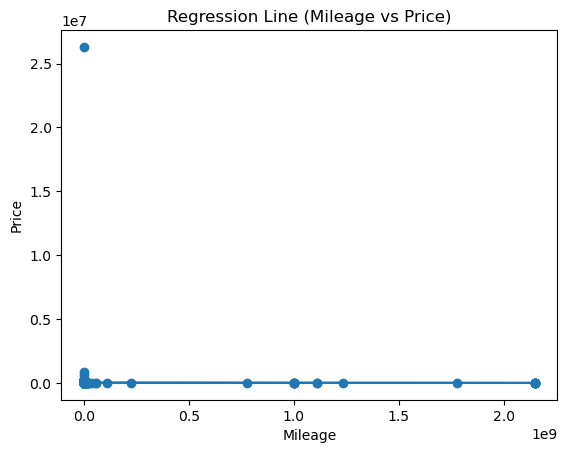

In [194]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X)

# Scatter plot (real data)
plt.scatter(X, y)

# Regression line
plt.plot(X, y_pred)

plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Regression Line (Mileage vs Price)')

plt.show()

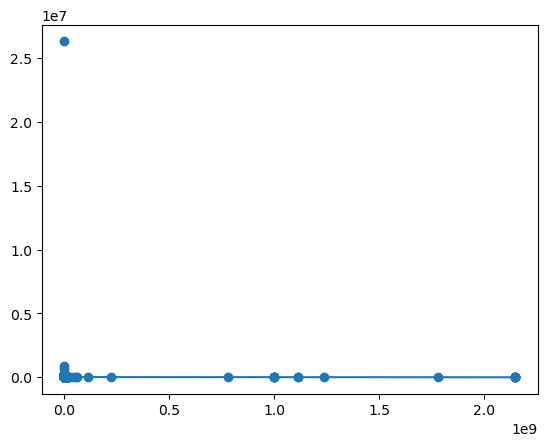

In [195]:
import numpy as np

sorted_index = np.argsort(X.values.flatten())
X_sorted = X.values.flatten()[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.scatter(X, y)
plt.plot(X_sorted, y_pred_sorted)

plt.show()

In [196]:
X = df[['Mileage','Engine volume','Manufacturer','Cylinders']]
y = df['Price']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [197]:
y_pred = model.predict(x_test)

In [198]:
print(x_train.columns)
print(x_test.columns)

Index(['Mileage', 'Engine volume', 'Manufacturer', 'Cylinders'], dtype='object')
Index(['Mileage', 'Engine volume', 'Manufacturer', 'Cylinders'], dtype='object')


In [199]:
print(model.coef_)
print(model.intercept_)

[-8.42295166e-06 -1.79243528e+03 -2.19738390e+01  1.91228585e+03]
14918.268862284873


In [200]:
model.intercept_

np.float64(14918.268862284873)

In [201]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 12862.696031254456
MSE: 333785196.6989873
R2: 0.007242751266553715


In [202]:
# Train model
model.fit(x_train, y_train)

# Save model
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [203]:
import os
print(os.getcwd())

C:\Users\Samuel Kwesi Nyarko\car-price-app
